# Métodos de reducción de dimensionalidad

## Análisis de correspondencias (AC)

In [3]:
# Análisis de correspondencias (AC)

import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

# Datos: Trabajadores
datos = (
    pd.read_excel("Trabajadores.xlsx")
)

# Vista rápida
display(datos.head())

# Dimensión
datos.shape

Saving Trabajadores.xlsx to Trabajadores (2).xlsx


,Sexo,Edad,Estado,Hijos,Escolaridad,Estrato,Ingresos,Ayuda,Dependen,Egresos,Situación,Créditos,Conocimiento
0,F,45,Casado,2,Posgrado,4+,8.800,No,3,8.410,Buena,Sin Créditos,0.249
1,M,36,Casado,2,Pregrado,3,5.920,No,1,3.915,Buena,Vigentes,0.491
2,M,61,Casado,3,Técnico,2,2.256,Sí,2,2.390,Difícil,Vigentes,0.449
3,F,40,Viudo,2,Posgrado,2,5.706,No,2,3.480,Buena,Vigentes,0.506
4,F,49,Casado,3,Posgrado,4+,9.450,Sí,1,2.900,Buena,Vigentes,0.675


(168, 13)

In [4]:
# Análisis de correspondencias simple

# Tabla de contingencia
N = pd.crosstab(datos["Estrato"], datos["Situación"])
display(N)

# Tabla de frecuencias relativas
P = N / N.to_numpy().sum()
display(P * 100)

Situación,Buena,Difícil,Regular
Estrato,,,
1,1,6,5
2,17,6,17
3,45,14,32
4+,21,1,3


Situación,Buena,Difícil,Regular
Estrato,,,
1,0.595238,3.571429,2.976190
2,10.119048,3.571429,10.119048
3,26.785714,8.333333,19.047619
4+,12.500000,0.595238,1.785714


In [6]:
# Función DVSG para AC
def dvsg(P):
    P_mat = P.to_numpy(dtype=float)
    s = min(P_mat.shape) - 1
    pf = P_mat.sum(axis=1)
    pc = P_mat.sum(axis=0)
    M = np.diag(1 / np.sqrt(pf))
    W = np.diag(1 / np.sqrt(pc))
    Z = P_mat - np.outer(pf, pc)
    U, d, Vt = np.linalg.svd(M @ Z @ W, full_matrices=False)
    dvsg = {
        "d": d[:s],
        "u": pd.DataFrame(
            np.linalg.solve(M, U[:, :s]),
            index=P.index,
            columns=[f"Dim.{i}" for i in range(1, s + 1)]
        ),
        "v": pd.DataFrame(
            np.linalg.solve(W, Vt.T[:, :s]),
            index=P.columns,
            columns=[f"Dim.{i}" for i in range(1, s + 1)]
        )
    }
    return dvsg

# Descomposición en valores singulares generalizada
dvs = dvsg(P)

In [7]:
# Valores propios
lamb = dvs["d"]**2
display(lamb)

# Matriz Delta
D = np.diag(dvs["d"])
display(D)

# Vectores propios filas
U = dvs["u"]
display(U)

# Vectores propios columnas
V = dvs["v"]
display(V)

array([0.13650644, 0.01814569])

array([[0.36946778, 0.        ],
       [0.        , 0.13470595]])

,Dim.1,Dim.2
Estrato,,
1,-0.191575,0.167009
2,-0.069110,-0.262864
3,-0.002682,-0.113805
4+,0.263367,0.209660


,Dim.1,Dim.2
Situación,,
Buena,0.472479,0.163597
Difícil,-0.259919,0.259475
Regular,-0.212559,-0.423071


In [8]:
# Dimensiones fila
pf = P.sum(axis=1).to_numpy()
Dr = np.diag(pf)
F = pd.DataFrame(
    np.linalg.solve(Dr, U.to_numpy()) @ D,
    index=P.index,
    columns=[f"Dim{i}" for i in range(1, U.shape[1] + 1)]
)
display(F)

,Dim1,Dim2
Estrato,,
1,-0.990929,0.314959
2,-0.107243,-0.148719
3,-0.001829,-0.028302
4+,0.653894,0.189789


In [9]:
# Dimensiones columna
pc = P.sum(axis=0).to_numpy()
Dc = np.diag(pc)
G = pd.DataFrame(
    np.linalg.solve(Dc, V.to_numpy()) @ D,
    index=P.columns,
    columns=[f"Dim{i}" for i in range(1, V.shape[1] + 1)]
)
display(G)

,Dim1,Dim2
Situación,,
Buena,0.349131,0.044075
Difícil,-0.597531,0.217484
Regular,-0.231468,-0.167971


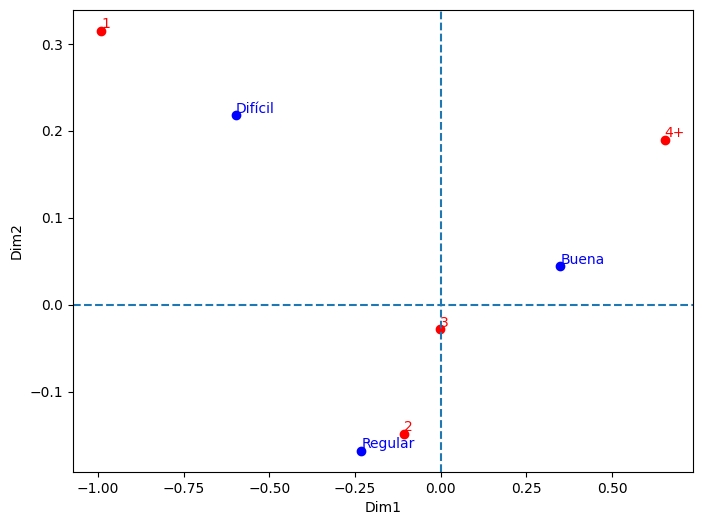

In [10]:
# Representación de filas y columnas
# Primeras dos dimensiones
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(F["Dim1"], F["Dim2"], color="red")
plt.scatter(G["Dim1"], G["Dim2"], color="blue")

for i in F.index:
    plt.text(F.loc[i, "Dim1"], F.loc[i, "Dim2"], i, color="red", va="bottom")

for i in G.index:
    plt.text(G.loc[i, "Dim1"], G.loc[i, "Dim2"], i, color="blue", va="bottom")

plt.axvline(x=0, linestyle="--")
plt.axhline(y=0, linestyle="--")

plt.xlabel("Dim1")
plt.ylabel("Dim2")
plt.show()

In [11]:
# cosenos cuadrados de las filas
cos2f = F.pow(2).div(F.pow(2).sum(axis=1), axis=0)
display(cos2f)

# cosenos cuadrados de las columnas
cos2c = G.pow(2).div(G.pow(2).sum(axis=1), axis=0)
display(cos2c)

,Dim1,Dim2
Estrato,,
1,0.908246,0.091754
2,0.342106,0.657894
3,0.004161,0.995839
4+,0.922303,0.077697


,Dim1,Dim2
Situación,,
Buena,0.984313,0.015687
Difícil,0.883022,0.116978
Regular,0.655047,0.344953


In [12]:
# Contribuciones de las filas
ctrf = F.pow(2).div(F.pow(2).sum(axis=0), axis=1)
display((ctrf * 100).round(1))

# Contribuciones de las columnas
ctrc = G.pow(2).div(G.pow(2).sum(axis=0), axis=1)
display((ctrc * 100).round(1))

,Dim1,Dim2
Estrato,,
1,69.1,62.7
2,0.8,14.0
3,0.0,0.5
4+,30.1,22.8


,Dim1,Dim2
Situación,,
Buena,22.9,2.5
Difícil,67.0,61.1
Regular,10.1,36.4


In [16]:
from scipy.stats import chi2_contingency

# Inercia de cada dimensión
inercia = lamb / lamb.sum() * 100
display(inercia)

# Inercia total
display(lamb.sum() * N.to_numpy().sum())

display(chi2_contingency(N)[0])

array([88.26676786, 11.73323214])

np.float64(25.981558383137322)

np.float64(25.981558383137326)

In [19]:
# Uso de la función CA de la librería prince
!pip install prince

import prince

ac = prince.CA(
    n_components=2,
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=123
)

ac = ac.fit(N)

,v. propio,inercia,iner. acum.
component,,,
0,0.137,88.27,88.27
1,0.018,11.73,100.00


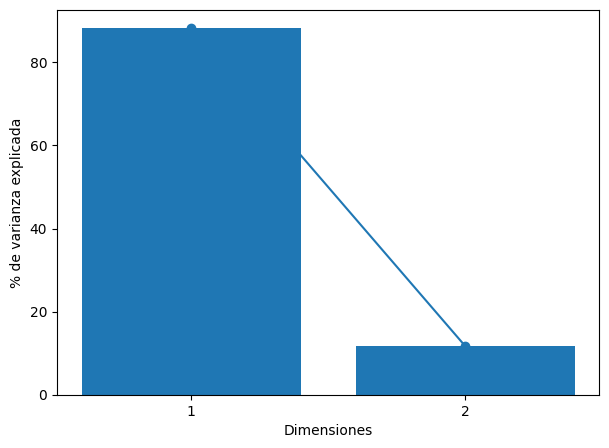

In [20]:
# Valores propios y porcentajes de inercia
eig = ac.eigenvalues_summary.copy()
eig.columns = ["v. propio", "inercia", "iner. acum."]

for col in ["inercia", "iner. acum."]:
    if eig[col].dtype == "O":
        eig[col] = eig[col].astype(str).str.replace("%", "", regex=False).astype(float)

display(eig)

# Histograma de valores propios (Scree Plot)
import matplotlib.pyplot as plt

x = np.arange(1, eig.shape[0] + 1)

plt.figure(figsize=(7, 5))
plt.bar(x, eig["inercia"])
plt.plot(x, eig["inercia"], marker="o")
plt.xticks(x)
plt.xlabel("Dimensiones")
plt.ylabel("% de varianza explicada")
plt.show()

In [21]:
# Coordenadas de las filas y columnas
display(ac.row_coordinates(N))      # filas
display(ac.column_coordinates(N))   # columnas

,0,1
Estrato,,
1,0.990929,0.314959
2,0.107243,-0.148719
3,0.001829,-0.028302
4+,-0.653894,0.189789


,0,1
Situación,,
Buena,-0.349131,0.044075
Difícil,0.597531,0.217484
Regular,0.231468,-0.167971


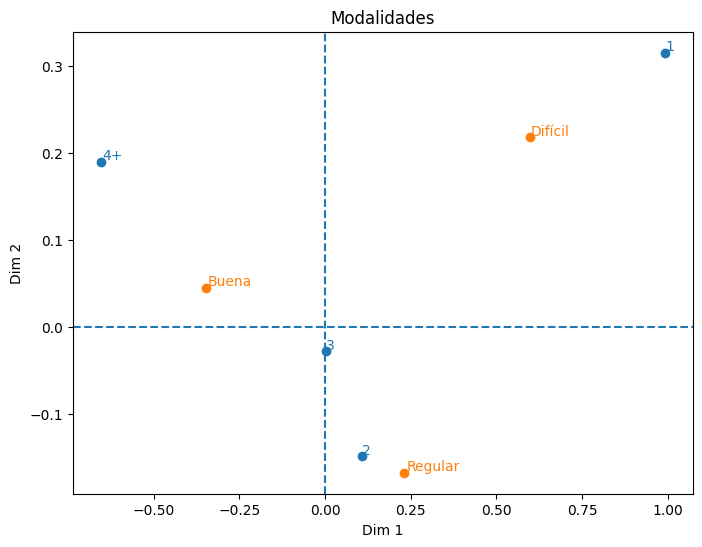

In [23]:
!pip install adjustText

# Representación de filas y columnas
from adjustText import adjust_text
import matplotlib.pyplot as plt

coord_filas = ac.row_coordinates(N).copy()
coord_columnas = ac.column_coordinates(N).copy()

plt.figure(figsize=(8, 6))

plt.scatter(coord_filas.iloc[:, 0], coord_filas.iloc[:, 1], color="C0")
plt.scatter(coord_columnas.iloc[:, 0], coord_columnas.iloc[:, 1], color="C1")

texts = []

for i in coord_filas.index:
    texts.append(
        plt.text(coord_filas.loc[i].iloc[0], coord_filas.loc[i].iloc[1], str(i), color="C0")
    )

for i in coord_columnas.index:
    texts.append(
        plt.text(coord_columnas.loc[i].iloc[0], coord_columnas.loc[i].iloc[1], str(i), color="C1")
    )

adjust_text(texts)

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("Modalidades")
plt.show()

In [24]:
# Cosenos cuadrados
display(ac.row_cosine_similarities(N))      # filas
display(ac.column_cosine_similarities(N))   # columnas

,0,1
Estrato,,
1,0.908246,0.091754
2,0.342106,0.657894
3,0.004161,0.995839
4+,0.922303,0.077697


,0,1
Situación,,
Buena,0.984313,0.015687
Difícil,0.883022,0.116978
Regular,0.655047,0.344953


In [25]:
# Contribuciones
display(ac.row_contributions_)      # filas
display(ac.column_contributions_)   # columnas

,0,1
1,0.513812,0.390487
2,0.020060,0.290209
3,0.000013,0.023911
4+,0.466115,0.295393


,0,1
Buena,0.446472,0.053528
Difícil,0.420361,0.418924
Regular,0.133166,0.527548


In [26]:
# Análisis de correspondencias múltiple

# Selección de variables categóricas
datos_acm = datos[["Estrato", "Situación", "Créditos"]].copy()

# Matriz indicadora
Z = pd.concat(
    [
        pd.get_dummies(datos_acm["Estrato"], dtype=int),
        pd.get_dummies(datos_acm["Situación"], dtype=int),
        pd.get_dummies(datos_acm["Créditos"], dtype=int),
    ],
    axis=1
)

display(Z.head(10))

,1,2,3,4+,Buena,Difícil,Regular,En Mora,Sin Créditos,Vigentes
0,0,0,0,1,1,0,0,0,1,0
1,0,0,1,0,1,0,0,0,0,1
2,0,1,0,0,0,1,0,0,0,1
3,0,1,0,0,1,0,0,0,0,1
4,0,0,0,1,1,0,0,0,0,1
5,0,1,0,0,0,0,1,0,0,1
6,0,0,1,0,0,0,1,0,0,1
7,0,0,1,0,1,0,0,1,0,0
8,0,0,1,0,1,0,0,0,0,1
9,0,0,1,0,0,0,1,1,0,0


In [27]:
# Matriz de probabilidad
Y = Z / Z.shape[0]

# Perfiles
pf = Y.sum(axis=1).to_numpy()
pc = Y.sum(axis=0).to_numpy()
M = np.diag(1 / np.sqrt(pf))
W = np.diag(1 / np.sqrt(pc))

# DVS
U, d, Vt = np.linalg.svd(
    M @ (Y.to_numpy(dtype=float) - np.outer(pf, pc)) @ W,
    full_matrices=False
)

dvs = {
    "d": d,
    "u": U,
    "v": Vt.T
}

In [28]:
# Valores propios
lamb = dvs["d"][1:8]**2
display(lamb)

# Matriz Delta
D = np.diag(dvs["d"][1:8])
display(D)

# Vectores propios de los individuos
U = pd.DataFrame(
    dvs["u"][:, 1:8],
    index=Y.index
)
display(U.head(10))  # primeras 10 filas

# Vectores propios de las modalidades
V = pd.DataFrame(
    dvs["v"][:, 1:8],
    index=Y.columns
)
display(V)

array([0.54065728, 0.41780188, 0.36033242, 0.322674  , 0.29024162,
       0.22678333, 0.17484279])

array([[0.73529401, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.64637596, 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.60027696, 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.56804402, 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.53874078,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.47621774, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.41814207]])

,0,1,2,3,4,5,6
0,-0.137944,0.149310,0.085020,0.084958,-0.071325,-0.110300,-0.079182
1,-0.025946,0.025666,-0.054926,-0.029613,0.013674,0.096107,0.024468
2,0.051144,-0.057665,0.104037,0.013310,0.174063,-0.005006,-0.100058
3,-0.053210,-0.055599,0.042051,0.020662,0.105129,0.027999,0.105618
4,-0.094520,0.066523,0.056140,-0.123987,-0.011984,-0.069455,0.011295
5,-0.011588,-0.146816,0.019267,0.032125,0.023819,-0.066920,0.022371
6,0.015676,-0.065551,-0.077710,-0.018149,-0.067636,0.001188,-0.058779
7,0.065048,0.111512,-0.098876,0.022086,0.030826,-0.056172,0.175699
8,-0.025946,0.025666,-0.054926,-0.029613,0.013674,0.096107,0.024468
9,0.106670,0.020294,-0.121659,0.033549,-0.050484,-0.151090,0.092452


,0,1,2,3,4,5,6
1,0.362000,0.015305,0.581926,0.012794,-0.516424,0.327207,0.291090
2,-0.125620,-0.476381,0.275411,0.324939,0.498133,-0.171740,0.245189
3,0.141761,0.149370,-0.546428,0.018249,-0.062744,0.276865,-0.190834
4+,-0.362365,0.306996,0.290978,-0.454700,-0.152598,-0.537685,-0.147727
Buena,-0.360596,0.320970,-0.021269,-0.024416,0.141185,0.283555,0.406895
Difícil,0.486141,0.169954,0.322824,-0.051430,0.414282,0.019306,-0.543328
Regular,0.103162,-0.506614,-0.196363,0.065037,-0.456521,-0.357509,-0.120008
En Mora,0.491831,0.339865,-0.197969,0.103022,0.091363,-0.487102,0.471353
Sin Créditos,-0.270952,0.300129,0.137978,0.751765,-0.218242,-0.061009,-0.306308
Vigentes,-0.097228,-0.249238,0.028334,-0.322383,0.044660,0.219322,-0.075759


In [29]:
# Dimensiones de los individuos
F = pd.DataFrame(
    M @ U.to_numpy() @ D,
    index=datos_acm.index,
    columns=[f"Dim{i}" for i in range(1, U.shape[1] + 1)]
)
display(F.head(10))  # primeras 10 filas

,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7
0,-0.759030,0.722218,0.381917,0.361144,-0.287551,-0.393073,-0.247767
1,-0.142767,0.124149,-0.246731,-0.125879,0.055127,0.342494,0.076563
2,0.281416,-0.278927,0.467342,0.056578,0.701746,-0.017838,-0.313089
3,-0.292787,-0.268933,0.188894,0.087831,0.423834,0.099778,0.330489
4,-0.520091,0.321772,0.252186,-0.527050,-0.048316,-0.247515,0.035343
5,-0.063765,-0.710156,0.086549,0.136559,0.096028,-0.238480,0.070001
6,0.086256,-0.317075,-0.349076,-0.077151,-0.272679,0.004235,-0.183925
7,0.357922,0.539386,-0.444156,0.093885,0.124276,-0.200180,0.549777
8,-0.142767,0.124149,-0.246731,-0.125879,0.055127,0.342494,0.076563
9,0.586944,0.098163,-0.546501,0.142613,-0.203529,-0.538438,0.289289


In [30]:
# Dimensiones de las modalidades
G = pd.DataFrame(
    W @ V.to_numpy() @ D,
    index=Y.columns,
    columns=[f"Dim{i}" for i in range(1, V.shape[1] + 1)]
)
display(G)

,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7
1,0.995940,0.037016,1.307024,0.027194,-1.041000,0.583032,0.455423
2,-0.189298,-0.631051,0.338811,0.378275,0.549984,-0.167610,0.210111
3,0.141629,0.131185,-0.445676,0.014085,-0.045929,0.179146,-0.108421
4+,-0.690704,0.514402,0.452790,-0.669563,-0.213115,-0.663771,-0.160128
Buena,-0.374970,0.293403,-0.018056,-0.019614,0.107568,0.190967,0.240614
Difícil,0.891653,0.274025,0.483382,-0.072874,0.556736,0.022933,-0.566707
Regular,0.130226,-0.562185,-0.202362,0.063425,-0.422239,-0.292287,-0.086149
En Mora,1.022874,0.621350,-0.336119,0.165522,0.139219,-0.656100,0.557462
Sin Créditos,-0.608657,0.592669,0.253034,1.304615,-0.359200,-0.088760,-0.391291
Vigentes,-0.081586,-0.183848,0.019410,-0.208985,0.027458,0.119192,-0.036151


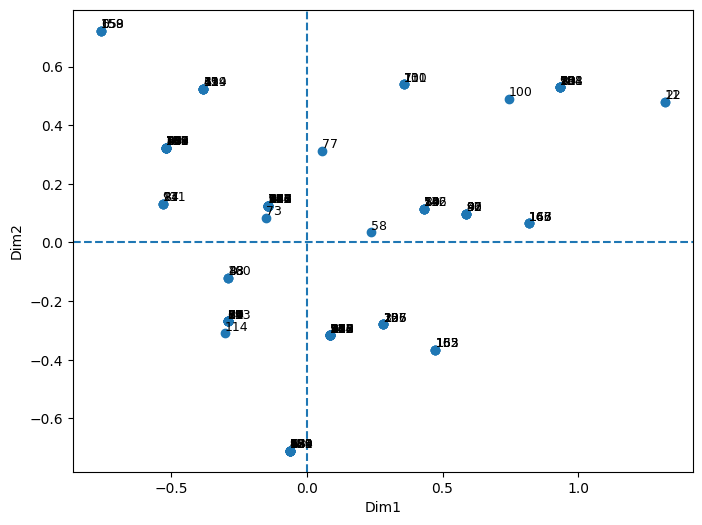

In [31]:
# Representación de los individuos
# Primeras dos dimensiones
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(F["Dim1"], F["Dim2"])

for i in F.index:
    plt.text(F.loc[i, "Dim1"], F.loc[i, "Dim2"], str(i), va="bottom", fontsize=9)

plt.axvline(x=0, linestyle="--")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Dim1")
plt.ylabel("Dim2")
plt.show()

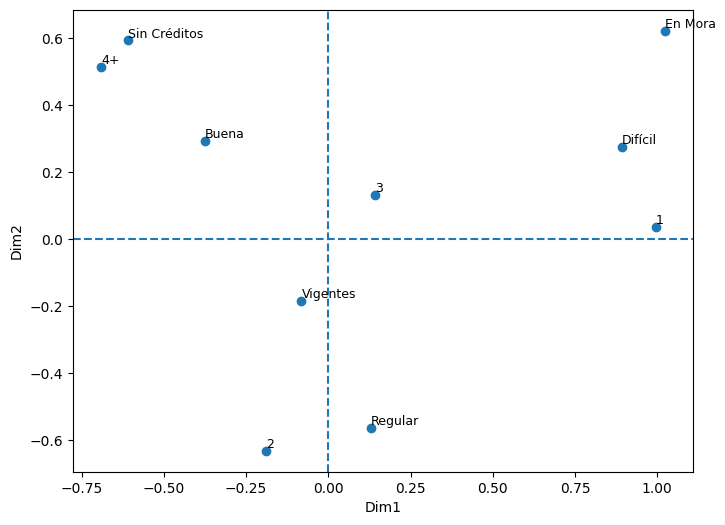

In [32]:
# Representación de las modalidades
# Primeras dos dimensiones
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(G["Dim1"], G["Dim2"])

for i in G.index:
    plt.text(G.loc[i, "Dim1"], G.loc[i, "Dim2"], str(i), va="bottom", fontsize=9)

plt.axvline(x=0, linestyle="--")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Dim1")
plt.ylabel("Dim2")
plt.show()

In [34]:
# Matriz de Burt
B = Z.T @ Z
display(B)

# Tabla de frecuencias relativas
P = B / B.to_numpy().sum()
display(P)

,1,2,3,4+,Buena,Difícil,Regular,En Mora,Sin Créditos,Vigentes
1,12,0,0,0,1,6,5,3,1,8
2,0,40,0,0,17,6,17,0,5,35
3,0,0,91,0,45,14,32,18,8,65
4+,0,0,0,25,21,1,3,0,4,21
Buena,1,17,45,21,84,0,0,5,15,64
Difícil,6,6,14,1,0,27,0,10,0,17
Regular,5,17,32,3,0,0,57,6,3,48
En Mora,3,0,18,0,5,10,6,21,0,0
Sin Créditos,1,5,8,4,15,0,3,0,18,0
Vigentes,8,35,65,21,64,17,48,0,0,129


,1,2,3,4+,Buena,Difícil,Regular,En Mora,Sin Créditos,Vigentes
1,0.007937,0.000000,0.000000,0.000000,0.000661,0.003968,0.003307,0.001984,0.000661,0.005291
2,0.000000,0.026455,0.000000,0.000000,0.011243,0.003968,0.011243,0.000000,0.003307,0.023148
3,0.000000,0.000000,0.060185,0.000000,0.029762,0.009259,0.021164,0.011905,0.005291,0.042989
4+,0.000000,0.000000,0.000000,0.016534,0.013889,0.000661,0.001984,0.000000,0.002646,0.013889
Buena,0.000661,0.011243,0.029762,0.013889,0.055556,0.000000,0.000000,0.003307,0.009921,0.042328
Difícil,0.003968,0.003968,0.009259,0.000661,0.000000,0.017857,0.000000,0.006614,0.000000,0.011243
Regular,0.003307,0.011243,0.021164,0.001984,0.000000,0.000000,0.037698,0.003968,0.001984,0.031746
En Mora,0.001984,0.000000,0.011905,0.000000,0.003307,0.006614,0.003968,0.013889,0.000000,0.000000
Sin Créditos,0.000661,0.003307,0.005291,0.002646,0.009921,0.000000,0.001984,0.000000,0.011905,0.000000
Vigentes,0.005291,0.023148,0.042989,0.013889,0.042328,0.011243,0.031746,0.000000,0.000000,0.085317


In [35]:
# DVSG
dvs = dvsg(P)

# Valores propios
lamb = dvs["d"]**2
display(lamb[:7])

# Matriz Delta
D = np.diag(dvs["d"])
display(D)

# Vectores propios filas
U = dvs["u"]
display(U.iloc[:, :7])

array([0.29231029, 0.17455841, 0.12983946, 0.10411851, 0.0842402 ,
       0.05143068, 0.03057   ])

array([[5.40657280e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 4.17801877e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 3.60332425e-01, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.22674003e-01,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        2.90241624e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.26783334e-01, 0.00000000e+00, 0.00000000e+00,
        0.0

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,Dim.6,Dim.7
1,-0.055858,0.002362,-0.089793,0.001974,0.079686,0.050489,-0.044916
2,0.035389,-0.134205,-0.077588,0.091541,-0.140333,-0.048382,-0.069074
3,-0.060237,0.063470,0.232187,0.007754,0.026661,0.117645,0.081089
4+,0.080705,0.068373,-0.064806,-0.101270,0.033986,-0.119752,0.032901
Buena,0.147213,0.131036,0.008683,-0.009968,-0.057639,0.115761,-0.166114
Difícil,-0.112520,0.039337,-0.074719,-0.011904,-0.095888,0.004468,0.125756
Regular,-0.034693,-0.170372,0.066036,0.021872,0.153526,-0.120229,0.040358
En Mora,-0.100395,0.069375,0.040410,0.021029,-0.018649,-0.099429,-0.096215
Sin Créditos,0.051205,0.056719,-0.026075,0.142070,0.041244,-0.011530,0.057887
Vigentes,0.049189,-0.126094,-0.014335,-0.163099,-0.022594,0.110959,0.038328


In [36]:
# Dimensiones fila
pf = P.sum(axis=1).to_numpy()
Dr = np.diag(pf)
F = pd.DataFrame(
    np.linalg.solve(Dr, U.to_numpy()) @ D,
    index=P.index,
    columns=[f"Dim{i}" for i in range(1, U.shape[1] + 1)]
)
display(F.iloc[:, :7])

,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7
1,-1.268395,0.041442,-1.358926,0.026755,0.971384,0.480904,-0.329837
2,0.241083,-0.706497,-0.352265,0.372178,-0.513205,-0.138251,-0.152171
3,-0.180374,0.146869,0.463373,0.013858,0.042857,0.147766,0.078523
4+,0.879658,0.575901,-0.470770,-0.658771,0.198863,-0.547501,0.115972
Buena,0.477550,0.328481,0.018773,-0.019298,-0.100375,0.157516,-0.174263
Difícil,-1.135579,0.306786,-0.502577,-0.071700,-0.519505,0.018916,0.410434
Regular,-0.165851,-0.629398,0.210398,0.062402,0.394002,-0.241088,0.062393
En Mora,-1.302698,0.695636,0.349466,0.162854,-0.129908,-0.541173,-0.403738
Sin Créditos,0.775165,0.663526,-0.263082,1.283586,0.335179,-0.073213,0.283390
Vigentes,0.103905,-0.205828,-0.020181,-0.205616,-0.025621,0.098314,0.026182


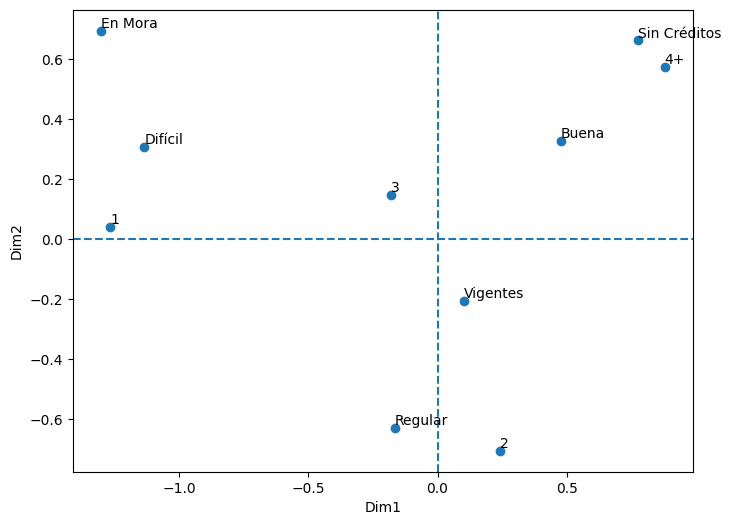

In [37]:
# Representación de las modalidades
# Primeras dos dimensiones
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(F["Dim1"], F["Dim2"])

for i in F.index:
    plt.text(F.loc[i, "Dim1"], F.loc[i, "Dim2"], str(i), va="bottom", fontsize=10)

plt.axvline(x=0, linestyle="--")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Dim1")
plt.ylabel("Dim2")
plt.show()

In [38]:
# Uso de la función MCA de prince
acm = prince.MCA(
    n_components=5,
    one_hot=True,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=123
)

acm = acm.fit(datos_acm)

In [39]:
# Valores propios y porcentajes de inercia
eig = acm.eigenvalues_summary.copy()
eig.columns = ["v. propio", "inercia", "iner. acum."]

for col in ["inercia", "iner. acum."]:
    if eig[col].dtype == "O":
        eig[col] = eig[col].astype(str).str.replace("%", "", regex=False).astype(float)

display(eig)

,v. propio,inercia,iner. acum.
component,,,
0,0.541,23.17,23.17
1,0.418,17.91,41.08
2,0.360,15.44,56.52
3,0.323,13.83,70.35
4,0.290,12.44,82.79


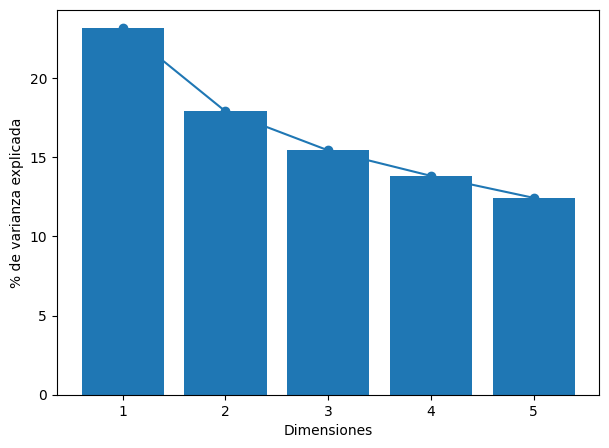

In [40]:
# Histograma de valores propios (Scree Plot)
import matplotlib.pyplot as plt

x = np.arange(1, eig.shape[0] + 1)

plt.figure(figsize=(7, 5))
plt.bar(x, eig["inercia"])
plt.plot(x, eig["inercia"], marker="o")
plt.xticks(x)
plt.xlabel("Dimensiones")
plt.ylabel("% de varianza explicada")
plt.show()

,0,1,2,3,4
0,-1.314679,1.250919,0.661500,0.625520,0.498053
1,-0.247279,0.215032,-0.427351,-0.218028,-0.095482
2,0.487426,-0.483115,0.809459,0.097996,-1.215459
3,-0.507122,-0.465806,0.327173,0.152129,-0.734102
4,-0.900825,0.557325,0.436799,-0.912877,0.083685
...,...,...,...,...,...
163,1.418070,0.113610,1.740693,-0.258838,0.489544
164,0.149399,-0.549189,-0.604618,-0.133629,0.472294
165,0.820201,-0.633302,1.081140,-0.120306,1.538678
166,1.418070,0.113610,1.740693,-0.258838,0.489544


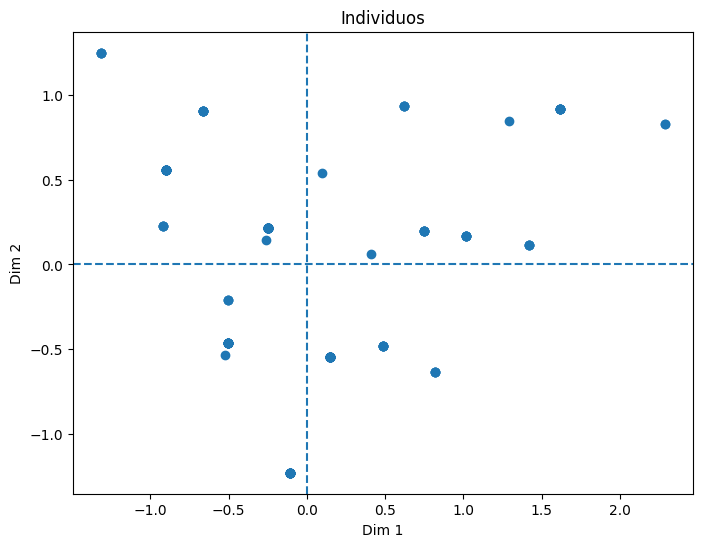

In [41]:
# Coordenadas de los individuos
coord_ind = acm.row_coordinates(datos_acm)
display(coord_ind)

# Representación de los individuos
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(coord_ind.iloc[:, 0], coord_ind.iloc[:, 1])
plt.axvline(x=0, linestyle="--")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("Individuos")
plt.show()

,0,1,2,3,4
Estrato__1,1.725018,0.064114,2.263832,0.047101,1.803064
Estrato__2,-0.327873,-1.093013,0.586838,0.655192,-0.952600
Estrato__3,0.245309,0.227219,-0.771933,0.024396,0.079551
Estrato__4+,-1.196335,0.890970,0.784255,-1.159718,0.369125
Situación__Buena,-0.649468,0.508189,-0.031274,-0.033973,-0.186314
Situación__Difícil,1.544388,0.474625,0.837242,-0.126222,-0.964294
Situación__Regular,0.225558,-0.973733,-0.350501,0.109855,0.731339
Créditos__En Mora,1.771670,1.076210,-0.582175,0.286692,-0.241134
Créditos__Sin Créditos,-1.054224,1.026532,0.438267,2.259660,0.622153
Créditos__Vigentes,-0.141310,-0.318434,0.033619,-0.361972,-0.047558


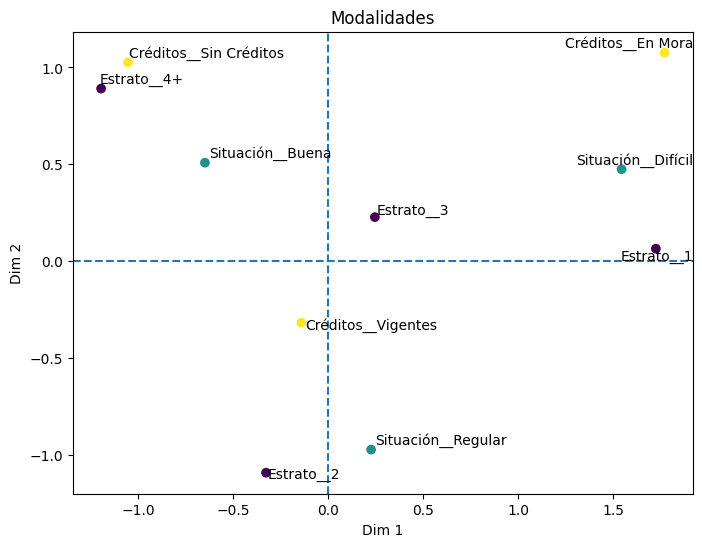

In [42]:
# Coordenadas de las modalidades de las variables
coord_var = acm.column_coordinates(datos_acm)
display(coord_var)

# Representación de las modalidades
col_var = np.repeat([1, 2, 3], [4, 3, 3])

from adjustText import adjust_text
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(coord_var.iloc[:, 0], coord_var.iloc[:, 1], c=col_var)

texts = []
for i in coord_var.index:
    texts.append(
        plt.text(coord_var.loc[i].iloc[0], coord_var.loc[i].iloc[1], str(i))
    )

adjust_text(texts)

plt.axvline(x=0, linestyle="--")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("Modalidades")
plt.show()

In [43]:
# Cosenos cuadrados
display(acm.column_cosine_similarities(datos_acm).round(3))

# Contribuciones
display(acm.column_contributions_.round(3))

,0,1,2,3,4
Estrato__1,0.229,0.000,0.394,0.000,0.250
Estrato__2,0.034,0.373,0.108,0.134,0.284
Estrato__3,0.071,0.061,0.704,0.001,0.007
Estrato__4+,0.250,0.139,0.108,0.235,0.024
Situación__Buena,0.422,0.258,0.001,0.001,0.035
Situación__Difícil,0.457,0.043,0.134,0.003,0.178
Situación__Regular,0.026,0.487,0.063,0.006,0.275
Créditos__En Mora,0.448,0.165,0.048,0.012,0.008
Créditos__Sin Créditos,0.133,0.126,0.023,0.613,0.046
Créditos__Vigentes,0.066,0.335,0.004,0.433,0.007


,0,1,2,3,4
Estrato__1,0.131,0.000,0.339,0.000,0.267
Estrato__2,0.016,0.227,0.076,0.106,0.248
Estrato__3,0.020,0.022,0.299,0.000,0.004
Estrato__4+,0.131,0.094,0.085,0.207,0.023
Situación__Buena,0.130,0.103,0.000,0.001,0.020
Situación__Difícil,0.236,0.029,0.104,0.003,0.172
Situación__Regular,0.011,0.257,0.039,0.004,0.208
Créditos__En Mora,0.242,0.116,0.039,0.011,0.008
Créditos__Sin Créditos,0.073,0.090,0.019,0.565,0.048
Créditos__Vigentes,0.009,0.062,0.001,0.104,0.002
